# 01 - Exploratory Data Analysis (EDA)

## Fuel Efficiency Prediction Project

In this notebook, we explore the Auto MPG dataset to understand the data before building a machine learning model.

The main goal of this project is to predict a car's fuel efficiency, measured as **MPG (Miles Per Gallon)**, using car-related features such as:

- Number of cylinders
- Engine displacement
- Horsepower
- Vehicle weight
- Acceleration
- Model year
- Origin country

EDA is important because it helps us understand:

- What columns are available
- Whether missing values exist
- How the target variable behaves
- Relationships between features
- Which features may be useful for prediction

In [2]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Set display option to show more columns clearly
pd.set_option("display.max_columns", None)

## 1. Load the Dataset

First, we load the raw dataset from the `data` folder.

The dataset file used here is:

`auto_mpg.csv`

This is the original dataset before cleaning.

In [3]:
# Load the dataset

df = pd.read_csv("../data/auto_mpg.csv")

# Display the first 5 rows
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


## 2. Understand the Dataset Shape

Now we check how many rows and columns are available in the dataset.

Rows represent cars, and columns represent information about each car.

In [4]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 398
Number of columns: 9


## 3. View Dataset Columns

Here, we check all column names in the dataset.

This helps us understand what information is available for prediction.

In [5]:
# Display all column names

df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name'],
      dtype='str')

## 4. Basic Dataset Information

The `.info()` function gives important information about the dataset:

- Column names
- Data types
- Number of non-null values
- Memory usage

This is useful to identify missing values and incorrect data types.

In [6]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


## 5. Statistical Summary

Now we check the statistical summary of the numerical columns.

This shows:

- Mean
- Standard deviation
- Minimum value
- Maximum value
- Quartiles

This helps us understand the range and distribution of numerical features.

In [7]:
# Display statistical summary of numerical columns

df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## 6. Check Missing Values

Missing values can affect machine learning model performance.

So, we check whether any column contains missing values.

In [8]:
# Check missing values in each column

missing_values = df.isnull().sum()

missing_values

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [9]:
# Show missing values as a percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

mpg             0.000000
cylinders       0.000000
displacement    0.000000
horsepower      1.507538
weight          0.000000
acceleration    0.000000
model_year      0.000000
origin          0.000000
car_name        0.000000
dtype: float64

### Missing Value Observation

From the missing value check, we can identify whether any column needs cleaning.

In this dataset, the most important column to check is **horsepower**, because vehicle horsepower is an important factor for predicting MPG.

If missing values are found, we will handle them properly in the next notebook.

## 7. Target Variable Analysis: MPG

The target variable of this project is:

`mpg`

MPG means **Miles Per Gallon**.

Higher MPG means the car is more fuel efficient.

Now we analyze the distribution of MPG.

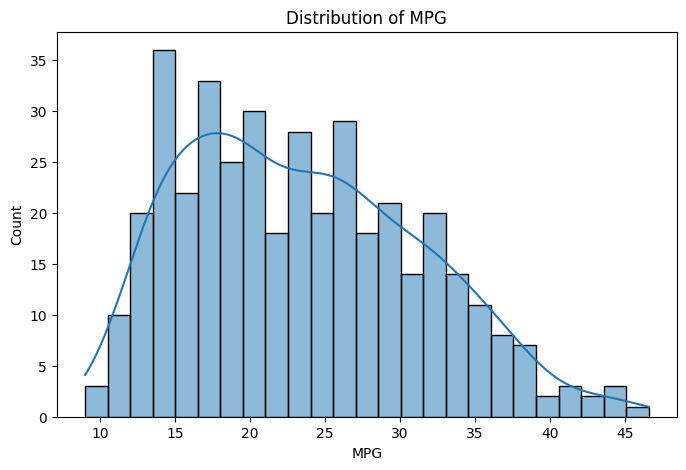

In [10]:
# Plot distribution of MPG

plt.figure(figsize=(8, 5))

sns.histplot(df["mpg"], bins=25, kde=True)

plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")

plt.show()

### MPG Distribution Observation

This graph helps us understand how fuel efficiency values are distributed.

From this graph, we can observe:

- Most cars are within a common MPG range
- Some cars have very high MPG
- The distribution helps us understand whether MPG values are balanced or skewed

This is important because MPG is the value our model will predict.

## 8. Relationship Between Weight and MPG

Vehicle weight is usually one of the most important factors affecting fuel efficiency.

Generally:

- Heavier cars use more fuel
- Lighter cars usually have better MPG

Now we visualize the relationship between `weight` and `mpg`.

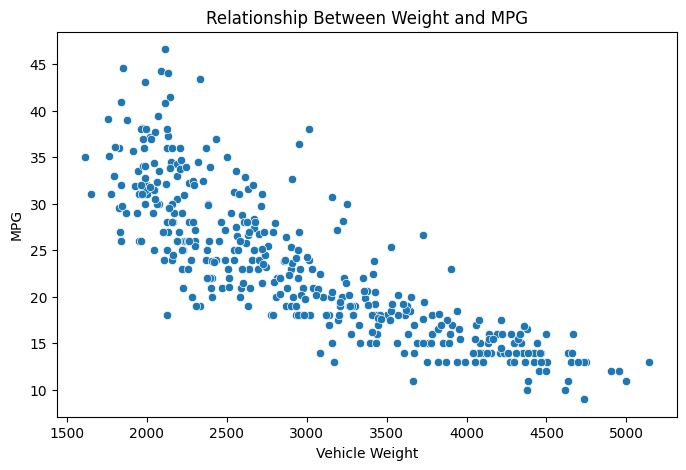

In [11]:
# Scatter plot: Weight vs MPG

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="weight", y="mpg")

plt.title("Relationship Between Weight and MPG")
plt.xlabel("Vehicle Weight")
plt.ylabel("MPG")

plt.show()

### Weight vs MPG Observation

The scatter plot shows the relationship between vehicle weight and fuel efficiency.

Usually, we expect to see a negative relationship:

- As weight increases, MPG decreases
- As weight decreases, MPG increases

This means weight can be an important feature for predicting fuel efficiency.

## 9. Relationship Between Horsepower and MPG

Horsepower represents engine power.

Usually:

- Cars with higher horsepower may consume more fuel
- Cars with lower horsepower may have better MPG

Now we check the relationship between `horsepower` and `mpg`.

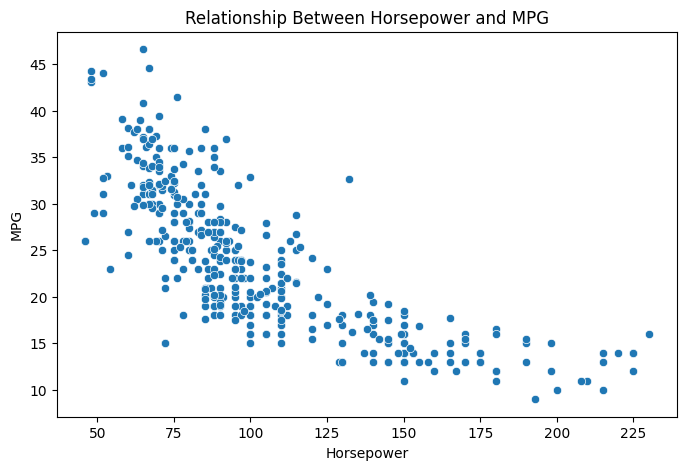

In [12]:
# Scatter plot: Horsepower vs MPG

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="horsepower", y="mpg")

plt.title("Relationship Between Horsepower and MPG")
plt.xlabel("Horsepower")
plt.ylabel("MPG")

plt.show()

### Horsepower vs MPG Observation

This graph helps us understand how engine power affects fuel efficiency.

Usually, cars with higher horsepower have lower MPG because powerful engines consume more fuel.

This feature may be useful for model training.

## 10. MPG by Number of Cylinders

The number of cylinders affects engine size and fuel consumption.

Usually:

- 4-cylinder cars are more fuel efficient
- 6-cylinder and 8-cylinder cars consume more fuel

Now we compare MPG values based on cylinder count.

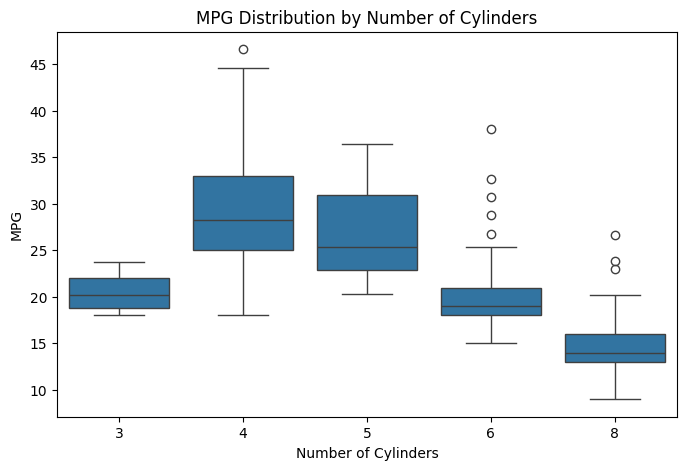

In [13]:
# Boxplot: Cylinders vs MPG

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="cylinders", y="mpg")

plt.title("MPG Distribution by Number of Cylinders")
plt.xlabel("Number of Cylinders")
plt.ylabel("MPG")

plt.show()

### Cylinders vs MPG Observation

This boxplot helps compare fuel efficiency between different cylinder groups.

From this chart, we can usually observe:

- Cars with fewer cylinders have higher MPG
- Cars with more cylinders have lower MPG

This means the number of cylinders is likely useful for prediction.

## 11. MPG by Origin

The `origin` column represents where the car was made.

In this dataset:

- 1 = USA
- 2 = Europe
- 3 = Japan

Now we compare MPG based on origin.

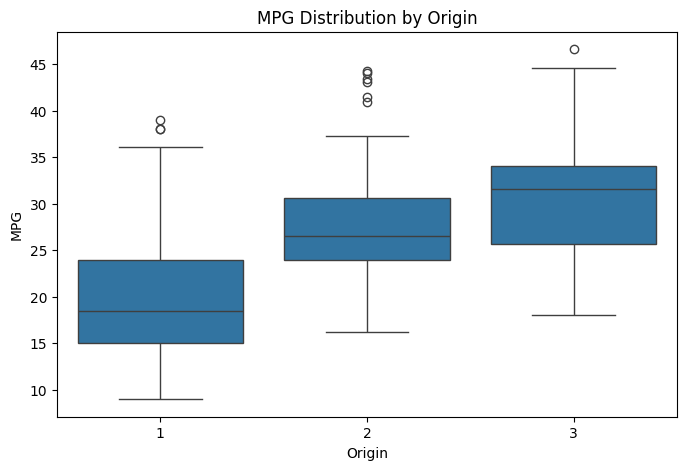

In [14]:
# Boxplot: Origin vs MPG

plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="origin", y="mpg")

plt.title("MPG Distribution by Origin")
plt.xlabel("Origin")
plt.ylabel("MPG")

plt.show()

### Origin vs MPG Observation

This chart helps us compare fuel efficiency by car origin.

Different regions may have different car designs, engine sizes, and fuel efficiency patterns.

This column will be converted into readable category names during data cleaning.

## 12. Correlation Analysis

Correlation shows how strongly numerical features are related to each other.

Important points:

- Correlation close to `1` means strong positive relationship
- Correlation close to `-1` means strong negative relationship
- Correlation close to `0` means weak relationship

We especially check how each feature is related to `mpg`.

In [15]:
# Select only numeric columns for correlation

numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation
correlation_matrix = numeric_df.corr()

correlation_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.416361,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.455171,-0.581024,0.205873,0.180662,1.000000


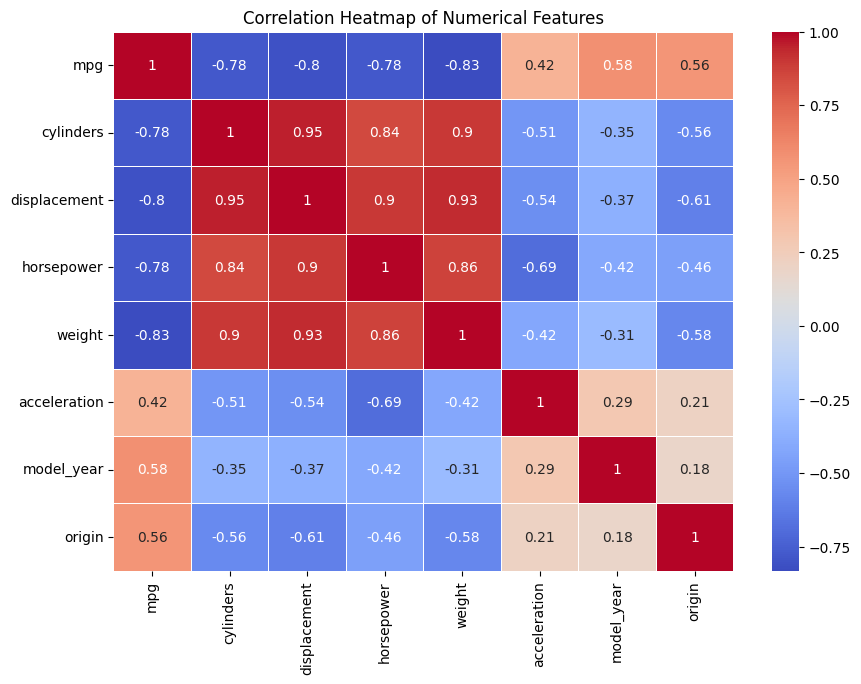

In [16]:
# Plot correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Correlation Observation

The heatmap helps us identify important relationships.

For this project, we mainly focus on features that are strongly related to MPG.

Usually:

- `weight` has a strong negative relationship with MPG
- `displacement` has a negative relationship with MPG
- `horsepower` has a negative relationship with MPG
- `model_year` may have a positive relationship with MPG

These features can help the model predict fuel efficiency.

## 13. MPG Trend by Model Year

Cars became more fuel efficient over time due to better technology and fuel economy improvements.

Now we check how average MPG changed by model year.

# Calculate average MPG by model year

mpg_by_year = df.groupby("model_year")["mpg"].mean().reset_index()

mpg_by_year

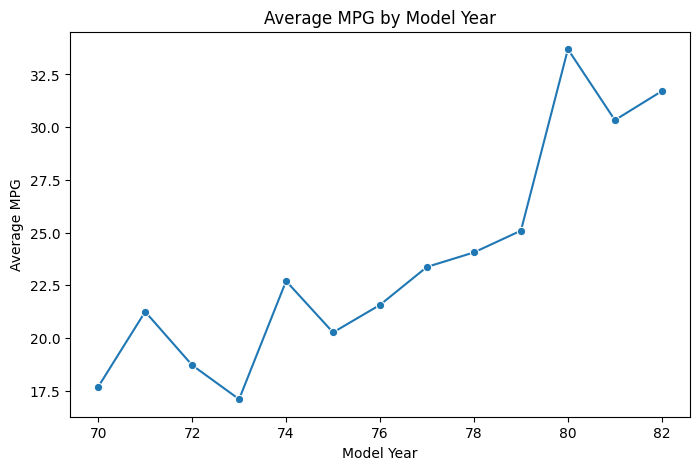

In [19]:
# Calculate average MPG by model year
mpg_by_year = df.groupby("model_year")["mpg"].mean().reset_index()

# Create line plot
plt.figure(figsize=(8, 5))

sns.lineplot(data=mpg_by_year, x="model_year", y="mpg", marker="o")

plt.title("Average MPG by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Average MPG")

plt.show()

### Model Year Observation

This line chart shows how fuel efficiency changed over time.

If average MPG increases over model years, it means newer cars became more fuel efficient.

This makes `model_year` a useful feature for prediction.

## 14. Pairplot for Important Features

A pairplot helps us quickly see relationships between multiple important columns.

Here, we use selected features only to keep the chart readable.

## 14. Pairplot for Important Features

A pairplot shows relationships between several numerical features at the same time.

Instead of using all columns, we use only the most important features to keep the chart clear and easy to understand.

Selected features:

- `mpg`
- `weight`
- `horsepower`
- `displacement`
- `model_year`

This helps us quickly identify patterns before building the machine learning model.

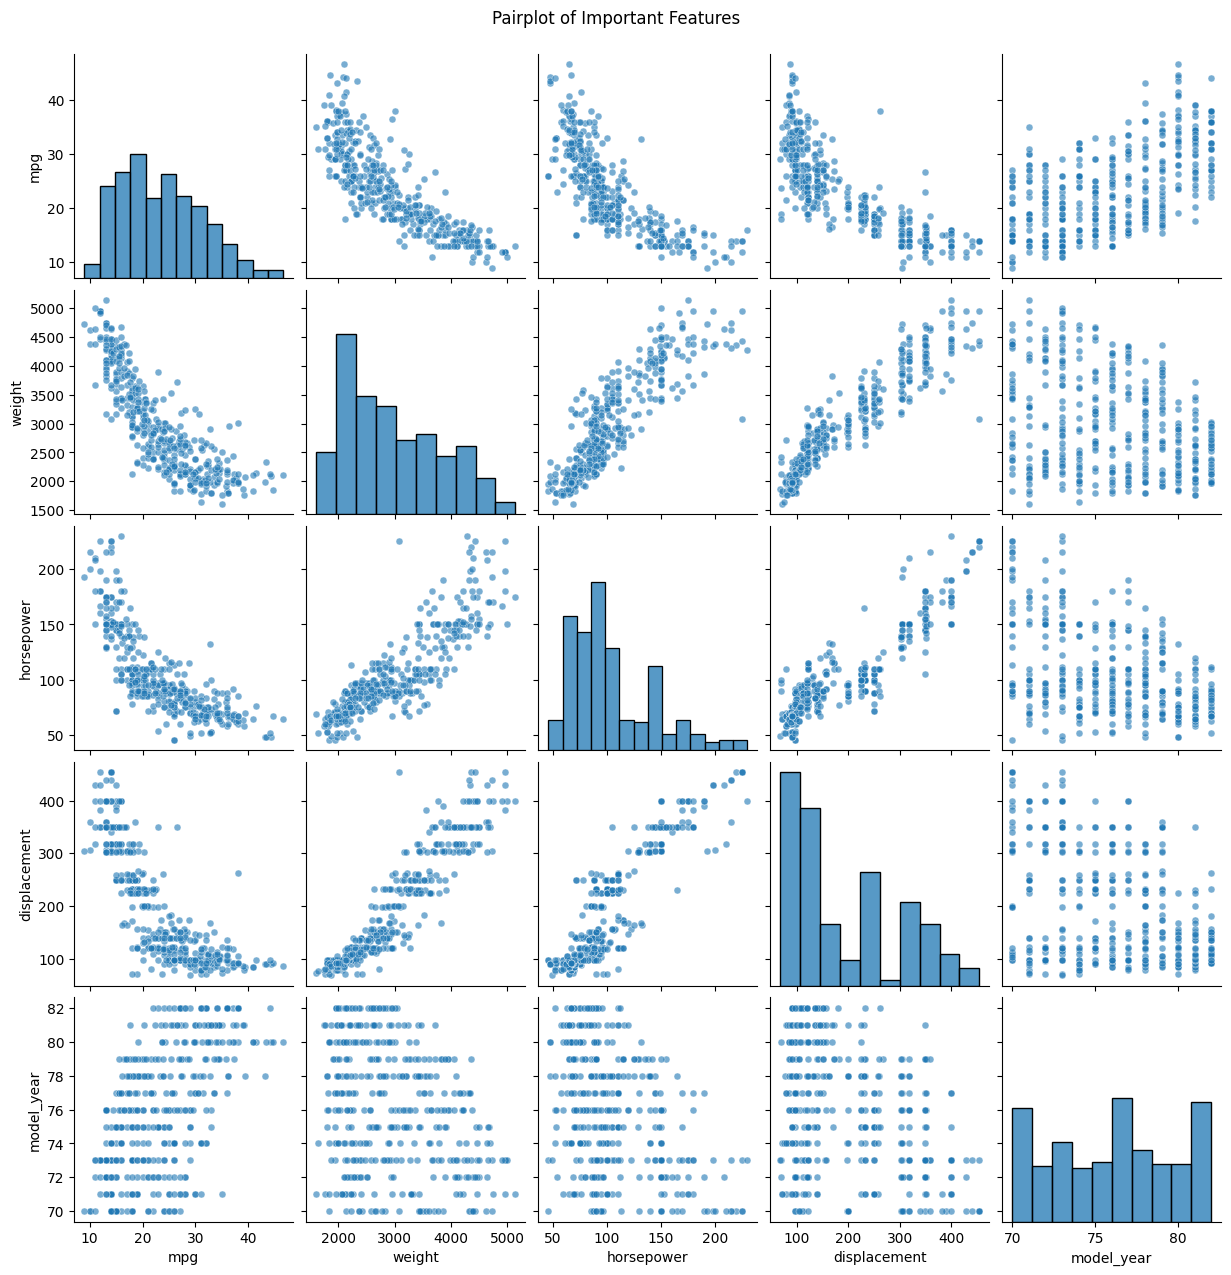

In [21]:
# Pairplot for only the most important features

# We select fewer columns to make the chart clear and readable
selected_columns = [
    "mpg",
    "weight",
    "horsepower",
    "displacement",
    "model_year"
]

# Create pairplot
sns.pairplot(
    df[selected_columns],
    diag_kind="hist",
    plot_kws={"alpha": 0.6, "s": 25}
)

plt.suptitle("Pairplot of Important Features", y=1.02)
plt.show()

### Pairplot Observation

From the pairplot, we can observe that:

- `weight` has a strong negative relationship with `mpg`
- `horsepower` also decreases as `mpg` increases
- `displacement` is related to both `weight` and `horsepower`
- Newer model years usually show better MPG values

This confirms that these features are useful for predicting fuel efficiency.

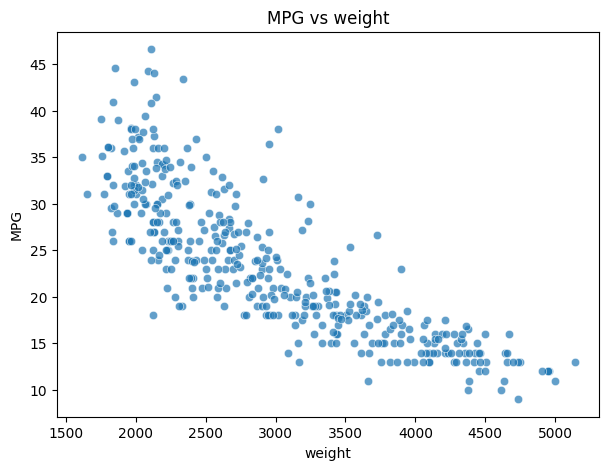

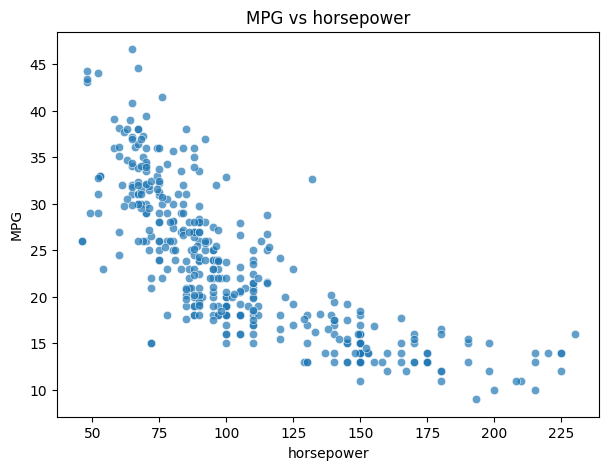

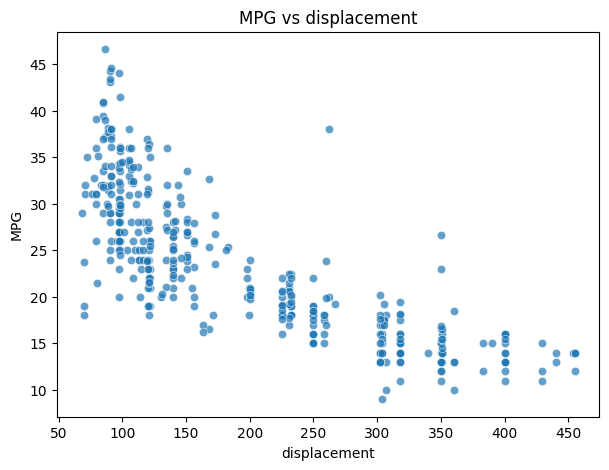

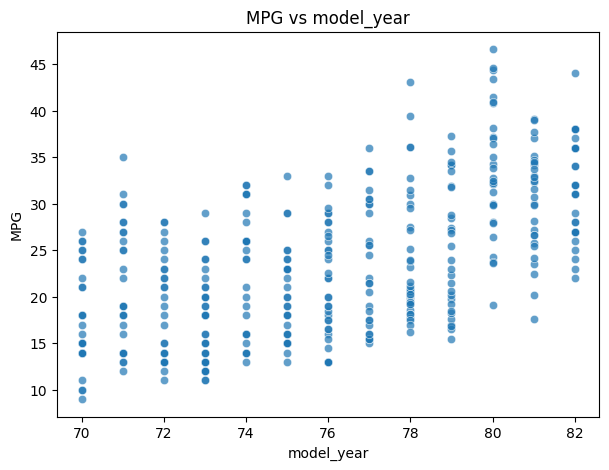

In [22]:
# Clean scatter plots for important relationships

important_features = ["weight", "horsepower", "displacement", "model_year"]

for feature in important_features:
    plt.figure(figsize=(7, 5))
    
    sns.scatterplot(data=df, x=feature, y="mpg", alpha=0.7)
    
    plt.title(f"MPG vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("MPG")
    
    plt.show()

## 15. Final EDA Summary

After exploring the dataset, we found several important points:

1. The target variable is `mpg`.
2. The dataset contains car engine and performance-related features.
3. Missing values should be checked and handled before modeling.
4. Weight has a strong relationship with MPG.
5. Horsepower and displacement also affect MPG.
6. Cars with fewer cylinders usually have better MPG.
7. Model year shows an important trend in fuel efficiency.
8. Origin may also affect MPG patterns.

In the next notebook, we will clean the dataset and prepare it for machine learning.